# Task 0


In [84]:
#a) I will use Hotel Booking Demand dataset that i found on Kaggle. Here's the link: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand

#b) The dataset contains contains booking information for a city hotel and a resort hotel, and includes information such as when the booking was made, length of stay, the number of adults, children, and/or babies, and the number of available parking spaces.
# It has  119390 rows and 32 columns. I plan to do analysis on the cancellations and customer behaviour, at least.

(119390, 32)


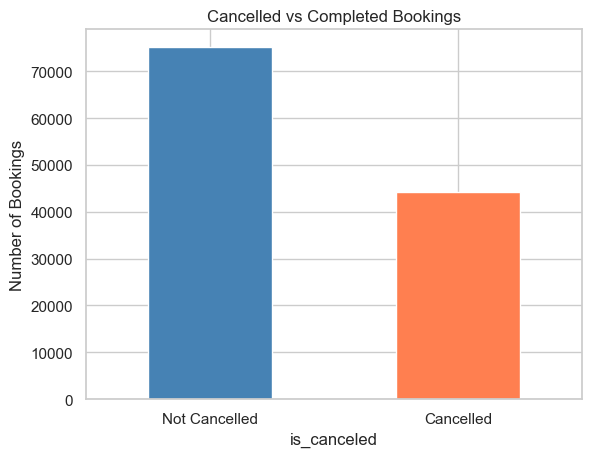

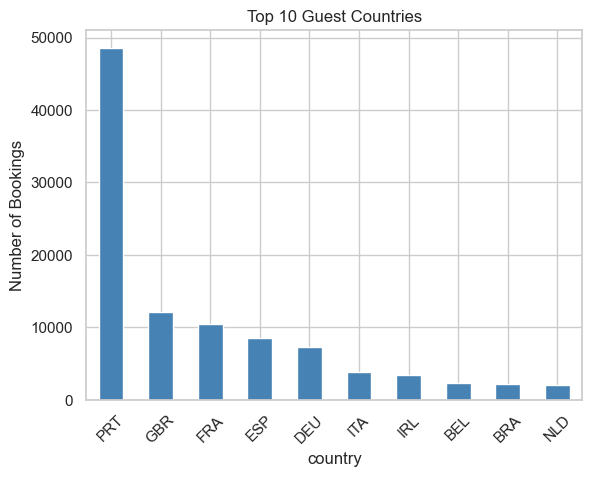

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

df = pd.read_csv('hotel_bookings.csv')
print(df.shape)
df.head()

# How many bookings were cancelled vs completed?
df['is_canceled'].value_counts().plot(kind='bar', color=['steelblue', 'coral'])
plt.xticks([0, 1], ['Not Cancelled', 'Cancelled'], rotation=0)
plt.title('Cancelled vs Completed Bookings')
plt.ylabel('Number of Bookings')
plt.show()

# Which countries do most guests come from?
df['country'].value_counts().head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 Guest Countries')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.show()

# Task 1

In [86]:
from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.getenv("MARKETSTACK_API_KEY")
print(api_key[:5] + "...")

35eba...


# Task 2

In [87]:
#a)

import requests
import pandas as pd

url = "http://api.marketstack.com/v1/eod"
params = {
    "access_key": api_key,
    "symbols": "META,AAPL,AMZN,NFLX,GOOG",
    "date_from": "2026-03-01",
    "date_to": "2026-03-31",
    "limit": 100
}

response = requests.get(url, params=params)
data = response.json()
print(data)


{'pagination': {'limit': 100, 'offset': 0, 'count': 100, 'total': 100}, 'data': [{'open': 247.89, 'high': 255.48, 'low': 247.101, 'close': 253.79, 'volume': 48770963.0, 'adj_high': 255.48, 'adj_low': 247.101, 'adj_close': 253.79, 'adj_open': 247.91, 'adj_volume': 49598091.0, 'split_factor': 1.0, 'dividend': 0.0, 'symbol': 'AAPL', 'exchange': 'XNAS', 'date': '2026-03-31T00:00:00+0000'}, {'open': 204.875, 'high': 210.28, 'low': 204.14, 'close': 208.27, 'volume': 57843337.0, 'adj_high': 210.28, 'adj_low': 204.14, 'adj_close': 208.27, 'adj_open': 204.845, 'adj_volume': 58470078.0, 'split_factor': 1.0, 'dividend': 0.0, 'symbol': 'AMZN', 'exchange': 'XNAS', 'date': '2026-03-31T00:00:00+0000'}, {'open': 277.84, 'high': 287.05, 'low': 276.81, 'close': 286.86, 'volume': 30680107.0, 'adj_high': 287.05, 'adj_low': 276.76, 'adj_close': 286.86, 'adj_open': 277.54, 'adj_volume': 31625057.0, 'split_factor': 1.0, 'dividend': 0.0, 'symbol': 'GOOG', 'exchange': 'XNAS', 'date': '2026-03-31T00:00:00+0000'

In [88]:
#b)

df=pd.DataFrame(data["data"])
display(df.head())

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31T00:00:00+0000
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31T00:00:00+0000
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31T00:00:00+0000
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31T00:00:00+0000
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31T00:00:00+0000


In [89]:
# c) Summary statistics for closing prices grouped by stock
summary = df.groupby("symbol")["close"].describe()
display(summary)

# Calculate return percentage (first to last trading day) for each stock
df["date"] = pd.to_datetime(df["date"])
df_sorted = df.sort_values("date")

returns = df_sorted.groupby("symbol").apply(
    lambda x: (x.iloc[-1]["close"] - x.iloc[0]["close"]) / x.iloc[0]["close"] * 100,
    include_groups=False
).reset_index()
returns.columns = ["symbol", "return_pct"]

display(returns)

# Best and worst performer
best = returns.loc[returns["return_pct"].idxmax(), "symbol"]
worst = returns.loc[returns["return_pct"].idxmin(), "symbol"]
print(f"Best performer in March 2026: {best}")
print(f"Worst performer in March 2026: {worst}")

,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
AAPL,20.0,253.9735,4.843451,246.63,250.0750,252.855,258.0650,262.52
AMZN,20.0,210.1385,4.856686,199.34,207.6375,210.005,213.2800,218.94
GOOG,20.0,297.2825,11.232111,273.14,289.4925,301.185,305.8000,309.41
META,20.0,611.0580,41.315247,525.72,593.4750,614.695,645.4925,667.73
NFLX,20.0,94.8445,2.518470,90.92,93.2325,94.530,96.3475,99.17


,symbol,return_pct
0,AAPL,-3.325461
1,AMZN,-3.943363
2,GOOG,-5.467128
3,META,-14.317164
4,NFLX,-2.544091


Best performer in March 2026: NFLX
Worst performer in March 2026: META


# Task 3

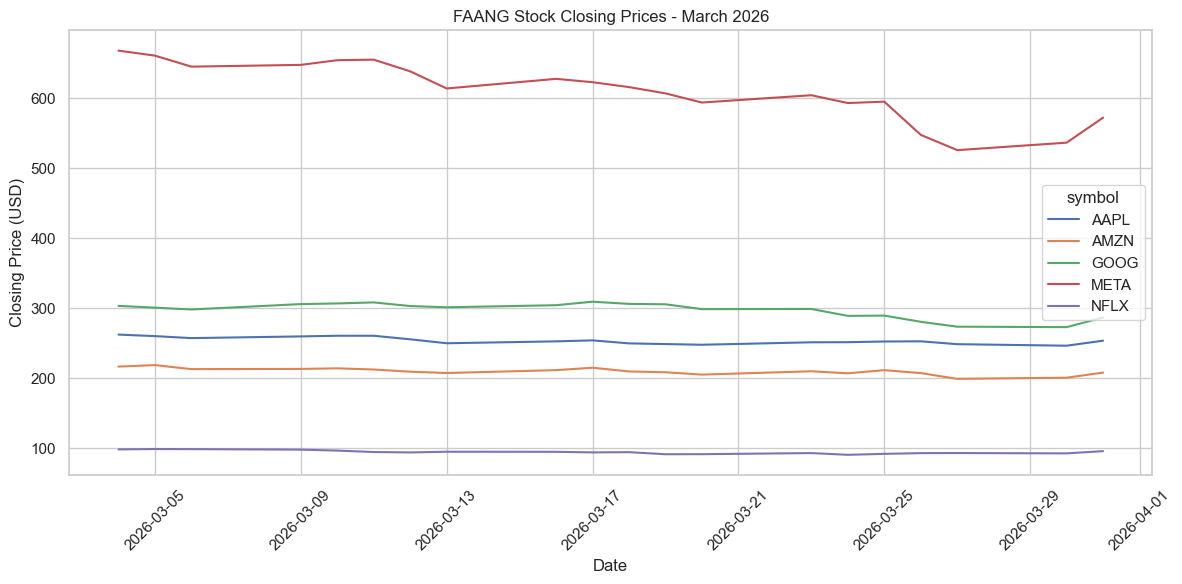

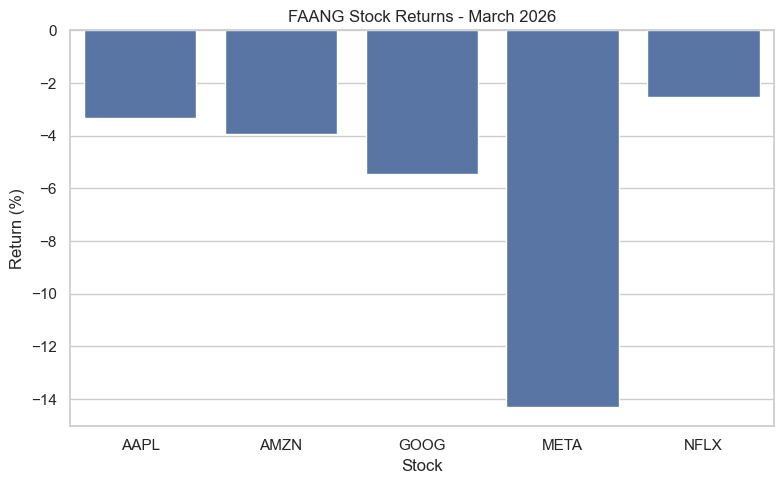

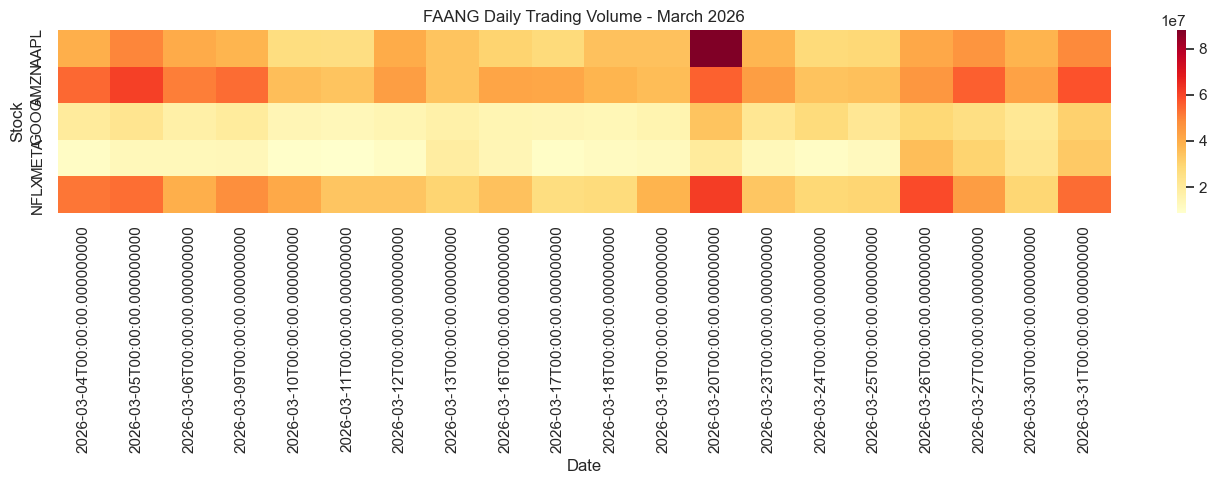

In [90]:
#a) line chart

import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(12,6))
sns.lineplot(data=df, x="date", y="close", hue="symbol")
plt.title("FAANG Stock Closing Prices - March 2026")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#b) bar plot

plt.figure(figsize=(8, 5))
sns.barplot(data=returns, x="symbol", y="return_pct")
plt.title("FAANG Stock Returns - March 2026")
plt.xlabel("Stock")
plt.ylabel("Return (%)")
plt.tight_layout()
plt.show()

#c) heat map
# First pivot the data so stocks are rows and dates are columns
volume_pivot = df.pivot(index="symbol", columns="date", values="volume")

plt.figure(figsize=(14, 5))
sns.heatmap(volume_pivot, cmap="YlOrRd", fmt=".0f")
plt.title("FAANG Daily Trading Volume - March 2026")
plt.xlabel("Date")
plt.ylabel("Stock")
plt.tight_layout()
plt.show()

# Task 4

In [91]:
#a)

import json
import os

os.makedirs("exports", exist_ok=True)

with open("exports/stockdata.json", "w") as f:
    json.dump(data, f)


#b)

df.to_csv("exports/stockdata.csv", index=False)

#c)

# load JSON back
with open("exports/stockdata.json") as f:
    data_back = json.load(f)

df_json_back = pd.DataFrame(data_back["data"])
print("From JSON:")
display(df_json_back.head())

# load CSV back
df_csv_back = pd.read_csv("exports/stockdata.csv")
print("From CSV:")
display(df_csv_back.head())

From JSON:


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31T00:00:00+0000
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31T00:00:00+0000
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31T00:00:00+0000
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31T00:00:00+0000
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31T00:00:00+0000


From CSV:


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31 00:00:00+00:00
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31 00:00:00+00:00
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31 00:00:00+00:00
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31 00:00:00+00:00
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31 00:00:00+00:00


# Task 5

In [92]:
#a)

import sqlite3

conn = sqlite3.connect("northwind.db")

tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)
print("Tables in Northwind database:")
display(tables)

#b)

df_products = pd.read_sql_query("""
    SELECT ProductName, UnitPrice, UnitsInStock
    FROM Products
    WHERE UnitPrice > 30
""", conn)

display(df_products)

#c)

df_germany = pd.read_sql_query("""
    SELECT c.CompanyName, o.OrderID, o.OrderDate, o.ShipCountry,
           od.UnitPrice * od.Quantity AS LineTotal
    FROM Orders o
    JOIN Customers c ON o.CustomerID = c.CustomerID
    JOIN 'Order Details' od ON o.OrderID = od.OrderID
    WHERE o.ShipCountry = 'Germany'
""", conn)

display(df_germany)

Tables in Northwind database:


,name
0,Categories
1,sqlite_sequence
2,CustomerCustomerDemo
3,CustomerDemographics
4,Customers
5,Employees
6,EmployeeTerritories
7,Order Details
8,Orders
9,Products


,ProductName,UnitPrice,UnitsInStock
0,Northwoods Cranberry Sauce,40.00,6
1,Mishi Kobe Niku,97.00,29
2,Ikura,31.00,31
3,Queso Manchego La Pastora,38.00,86
4,Alice Mutton,39.00,0
5,Carnarvon Tigers,62.50,42
6,Sir Rodney's Marmalade,81.00,40
7,Gumbär Gummibärchen,31.23,15
8,Schoggi Schokolade,43.90,49
9,Rössle Sauerkraut,45.60,26


,CompanyName,OrderID,OrderDate,ShipCountry,LineTotal
0,Toms Spezialitäten,10249,2016-07-05,Germany,167.4
1,Toms Spezialitäten,10249,2016-07-05,Germany,1696.0
2,Ottilies Käseladen,10260,2016-07-19,Germany,123.2
3,Ottilies Käseladen,10260,2016-07-19,Germany,780.0
4,Ottilies Käseladen,10260,2016-07-19,Germany,591.0
...,...,...,...,...,...
80668,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,864.0
80669,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,735.0
80670,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,75.0
80671,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,500.0


# Task 6

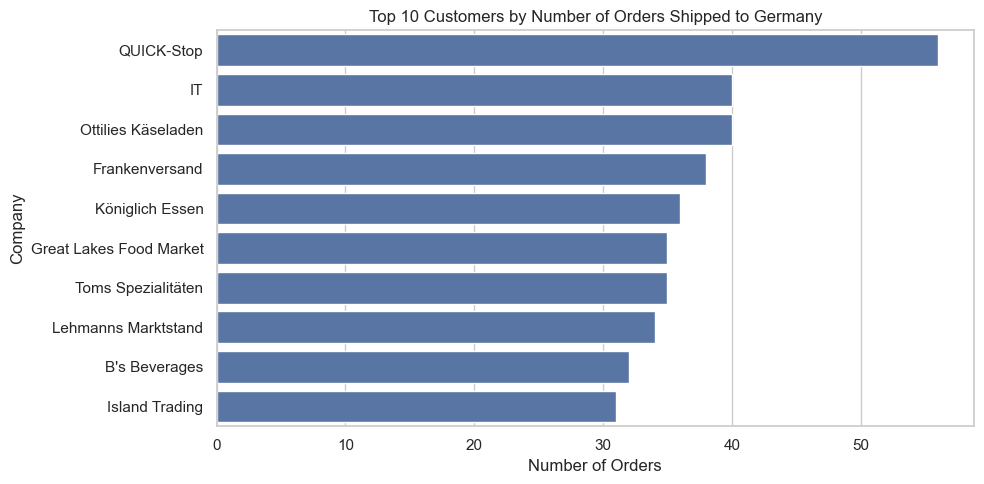

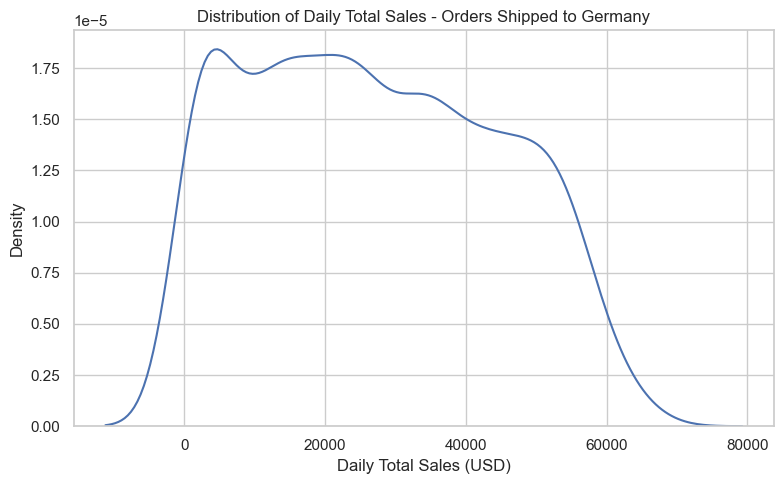

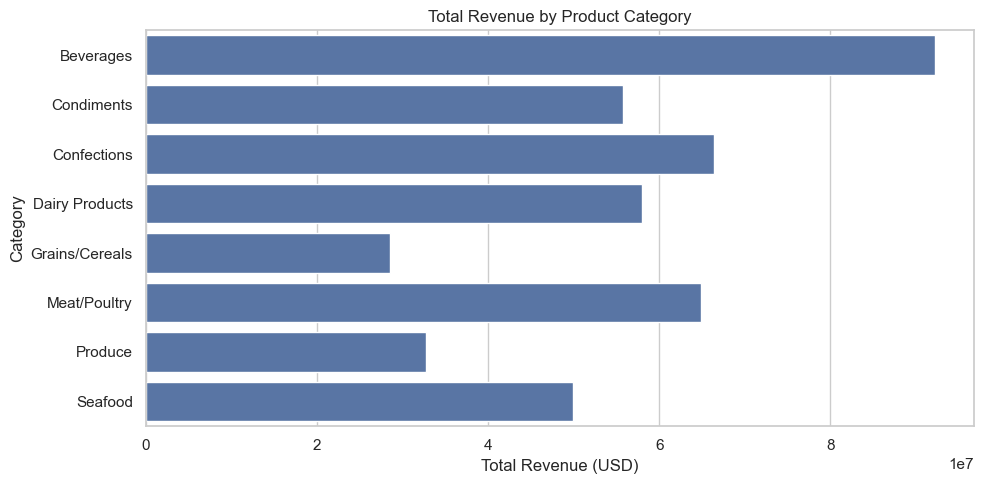

In [93]:
#a)

top10 = df_germany.groupby("CompanyName")["OrderID"].nunique().nlargest(10).reset_index()
top10.columns = ["CompanyName", "order_count"]

plt.figure(figsize=(10, 5))
sns.barplot(data=top10, x="order_count", y="CompanyName")
plt.title("Top 10 Customers by Number of Orders Shipped to Germany")
plt.xlabel("Number of Orders")
plt.ylabel("Company")
plt.tight_layout()
plt.show()

#b)

df_germany["OrderDate"] = pd.to_datetime(df_germany["OrderDate"], format='mixed')
daily_sales = df_germany.groupby("OrderDate")["LineTotal"].sum().reset_index()

plt.figure(figsize=(8, 5))
sns.kdeplot(data=daily_sales, x="LineTotal")
plt.title("Distribution of Daily Total Sales - Orders Shipped to Germany")
plt.xlabel("Daily Total Sales (USD)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

#c)

df_revenue = pd.read_sql_query("""
    SELECT cat.CategoryName,
           SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
    FROM 'Order Details' od
    JOIN Products p ON od.ProductID = p.ProductID
    JOIN Categories cat ON p.CategoryID = cat.CategoryID
    GROUP BY cat.CategoryName
""", conn)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_revenue, x="TotalRevenue", y="CategoryName")
plt.title("Total Revenue by Product Category")
plt.xlabel("Total Revenue (USD)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


# Task 7

In [94]:
df_products_full = pd.read_sql_query("SELECT * FROM Products", conn)
df_categories_full = pd.read_sql_query("SELECT * FROM Categories", conn)
df_categories_full = df_categories_full.drop(columns=["Picture"])
print("Products:")
display(df_products_full.head())
print("Categories:")
display(df_categories_full.head())

#b)

df_joined = pd.merge(df_products_full, df_categories_full, on="CategoryID", how="inner")
display(df_joined.head())

#c)

import time

# SQL approach
start_sql = time.time()
df_sql = pd.read_sql_query("""
    SELECT cat.CategoryName,
           SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
    FROM 'Order Details' od
    JOIN Products p ON od.ProductID = p.ProductID
    JOIN Categories cat ON p.CategoryID = cat.CategoryID
    GROUP BY cat.CategoryName
""", conn)
end_sql = time.time()
sql_time = end_sql - start_sql

# Python/pandas approach
start_pandas = time.time()
df_od = pd.read_sql_query("SELECT * FROM 'Order Details'", conn)
df_p = pd.read_sql_query("SELECT * FROM Products", conn)
df_c = pd.read_sql_query("SELECT * FROM Categories", conn)


df_merged = pd.merge(df_od, df_p, on="ProductID", how="inner")
df_merged = pd.merge(df_merged, df_c, on="CategoryID", how="inner")
df_merged["Revenue"] = df_merged["UnitPrice_x"] * df_merged["Quantity"]
df_pandas = df_merged.groupby("CategoryName")["Revenue"].sum().reset_index()
end_pandas = time.time()
pandas_time = end_pandas - start_pandas

print(f"SQL execution time:    {sql_time:.4f} seconds")
print(f"Pandas execution time: {pandas_time:.4f} seconds")

#c = comment on SQL vs Pandas = SQL's execution time was much faster than the Pandas approach. This is because the join and aggregation happens inside the databse engine, isntead of having to load all raw data as pandas does.

Products:


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


Categories:


,CategoryID,CategoryName,Description
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales"
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an..."
2,3,Confections,"Desserts, candies, and sweet breads"
3,4,Dairy Products,Cheeses
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal"


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued,CategoryName,Description
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0,Beverages,"Soft drinks, coffees, teas, beers, and ales"
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0,Beverages,"Soft drinks, coffees, teas, beers, and ales"
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0,Condiments,"Sweet and savory sauces, relishes, spreads, an..."
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0,Condiments,"Sweet and savory sauces, relishes, spreads, an..."
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1,Condiments,"Sweet and savory sauces, relishes, spreads, an..."


SQL execution time:    1.7397 seconds
Pandas execution time: 4.9288 seconds


# Task 8

In [95]:
#a)

print("a)")

wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

print("Before (wide format):")
display(wide_data)

long_data_converted = pd.melt(wide_data, id_vars="store", 
                               var_name="quarter", value_name="sales")

print("After (long format):")
display(long_data_converted)

#b)

print("b)")


long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})

print("Before (long format):")
display(long_data)

wide_data_converted = long_data.pivot(index="month", columns="product", values="units_sold")

print("After (wide format):")
display(wide_data_converted)

#c)

print("c)")
# Long back to wide (undo melt)
wide_restored = long_data_converted.pivot(index="store", columns="quarter", values="sales").reset_index()
wide_restored.columns.name = None
print("Wide restored:")
display(wide_restored)

# Wide back to long (undo pivot)
long_restored = pd.melt(wide_data_converted.reset_index(), id_vars="month",
                         var_name="product", value_name="units_sold")
print("Long restored:")
display(long_restored)


a)
Before (wide format):


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


After (long format):


,store,quarter,sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


b)
Before (long format):


...

product,Laptop,Phone
month,,
Feb,50,110
Jan,45,120
Mar,55,130


c)
Wide restored:


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


Long restored:


,month,product,units_sold
0,Feb,Laptop,50
1,Jan,Laptop,45
2,Mar,Laptop,55
3,Feb,Phone,110
4,Jan,Phone,120
5,Mar,Phone,130


# AI statement 

In [96]:
# I did use AI as aid for this assignment. I used it more than I did for the last assginment, as I felt the tasks were quite a lot more difficult.
# I especially used AI for the vizualisations, as I did not know how to do them properly.
# The AI tool that was used for this assignment was Claude.